This notebook includes development of hahn echo experiment and it's comparision with ramsey (T2*) and parameter sweep analysis.

Although the Ramsey experiment had previously been implemented using the Lindblad master equation, it is reimplemented in this notebook using the Bloch sphere formalism. This implementation provides a more intuitive understanding of qubit state evolution under pulse sequences and the effects of dephasing on coherence. Furthermore, developing both the Ramsey  and Hahn Echo experiments within the same simulation framework enables a consistent comparison of their ability to characterize qubit coherence.

The Hahn Echo experiment consists of a π/2 pulse, followed by free evolution for τ/2, a π refocusing pulse, another free evolution period of τ/2, and a final π/2 pulse before measurement. The π pulse reverses the accumulated phase due to slowly varying noise, allowing the Hahn Echo sequence to recover coherence that is lost in the Ramsey experiment and provide a more accurate estimate of the intrinsic coherence time.

The standard Lindblad master equation assumes Markovian dynamics, meaning the environment has no memory of its past interactions with the qubit. Consequently, it cannot capture the refocusing effect of the Hahn Echo sequence, which is designed to suppress phase errors arising from slowly varying (quasi-static) dephasing noise. Under a purely Markovian noise model, the π pulse does not recover any lost coherence, leading to an extracted coherence time of T2_echo ≌ T2*. As a result, the Hahn Echo experiment provides little additional information beyond the Ramsey experiment within this model.

To over-come this problem we need to model two contributions separately:
1. Markovian/dynamic part --> Lindblad-like T1 decay + a small dynamic Tphi(Not refocused by the echo pulse). Governs the echo decay
2. Quasi-static part --> a random detuning delta, drawn fresh for each monte carlo "shot" and held fixed for that shot --> IS refocused by the echo pulse. Governs the extra decay seen in Ramsey(T2*) but not in Echo.

To study the effect of pure dephasing, T
ϕ is varied over one order of magnitude while keeping T
1constant. The resulting T2* and T2_echo values are plotted to compare the response of the Ramsey and Hahn Echo experiments.

In [1]:
import os
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [2]:
T1_DEFAULT = 100e-6
#energy relaxation time
T2_STAR_DEFAULT = 50e-6
#refrence ramsey T2*
T_PHI_DYNAMIC = 150e-6
#refrence dynamic(markovian) dephasing budget
N_SHOTS = 4000
#Monte Carlo shots per tau point
RNG_SEED = 42

instantaneous rotation of the Bloch vector about X axis by 'angle' is given by-

In [3]:
def rx_pulse(r, angle):
  """Parameters
  r : Initial Bloch vector represented as [rx, ry, rz].
  angle : Rotation angle about the X-axis
  returns
  The updated Bloch vector after applying the X-axis rotation."""
  rx, ry, rz = r
  c = np.cos(angle / 2)
  s = np.sin(angle / 2)
  return [rx, c * ry - s * rz, c * rz + s * ry]
#is standard mathematical formula and nothing to do with quantum

free evolution of qubit

In [4]:
def free_evolution(r, t, delta, T1_, T2_):
  """Parameters
  r : Initial Bloch vector represented as [rx, ry, rz].
  t : Free evolution time of the qubit.
  delta : Qubit detuning (angular frequency) responsible for phase precession during free evolution
  T1_ : Energy relaxation time constant.
  T2_ : Transverse relaxation (dephasing) time constant.
  Returns
  The Bloch vector after free evolution, including phase precession, energy relaxation (T1), and dephasing (T2)."""
  rx0, ry0, rz0 = r
  #extracted the initial bloch sphere vector components
  r_eq_z = -1.0
  #thermal ground state at low temperature
  prep0 = rx0 + 1j *ry0
  #represents the transverse (x-y plane) components as a complex number
  prep_t = prep0* np.exp(-t/T2_) * np.exp(1j *delta *t)
  #applied dephasing(T2 decay) and phase rotation due to detuning
  rx_t = prep_t.real
  #recovers the updated X-component
  ry_t = prep_t.imag
  #recovers the updated Y-component
  rz_t = r_eq_z + (rz0 - r_eq_z) * np.exp(-t/T1_)
  #applies the longitudonal relaxation (T1 decay) towards the ground state.
  return ([rx_t, ry_t, rz_t])

ramsey experiment (∏/2 --> free evolution --> ∏/2)

In [5]:
def ramsey_shot(tau, delta, T1_, T2_dynamic):
  """Parameters
  tau : Free evolution time between two ∏/2 pulses.
  delta : Qubit detuning (angular frequency) responsible for phase accumulation during free evolution period.
  T1_ : Energy relaxation time constant.
  T2_dynamic : Transverse relaxation (dephasing) time constant for the dynamic part of the free evolution.
  Returns
  Final z-component of the bloch vector after the ramsey sequence, corresponding to the measurement outcome along the z-axis."""
  r = np.array([0.0, 0.0, -1.0])
  #start in |0>
  r = rx_pulse(r, np.pi/2)
  #prepares |+>
  r = free_evolution(r, tau, delta, T1_, T2_dynamic)
  r = rx_pulse(r, np.pi/2)
  #second pi/2
  return r[2]

Hahn-echo experiment(∏/2 --(tau/2)--> ∏ --(tau/2) --> ∏/2)

In [6]:
def hahn_echo_shot(tau, delta, T1_, T2_dynamic):
  """Parameters
  tau : Free evolution time between two ∏/2 pulses.
  delta : Qubit detuning (angular frequency) responsible for phase accumulation during free evolution period.
  T1_ : Energy relaxation time constant.
  T2_dynamic : Transverse relaxation (dephasing) time constant for the dynamic part of the free evolution.
  Returns
  Final z-component of the Bloch vector after completing the hahn echo pulse sequence."""
  r = np.array([0.0, 0.0, -1.0])
  # start in |0>
  r = rx_pulse(r, np.pi/2)
  #prepare |+>
  r = free_evolution(r, tau/2, delta, T1_, T2_dynamic)
  r = rx_pulse(r, np.pi)
  #refocusing the pulse
  r = free_evolution(r, tau/2, delta, T1_, T2_dynamic)
  #second half
  r = rx_pulse(r, np.pi/2)
  return r[2]

Monte Carlo average over quasi-static detuning

In [7]:
def ensemble_average(shot_fn, tau, T1_, T2_dynamic, gamma_static, n_shots = N_SHOTS, rng = None):
  """shot_fn : callable function representing a single-shot experiment(ramsey or hahn echo)
  tau : Total free evolution time for the experiment
  T1_ : energy relaxation time constant
  T2_dynamic : dynamic dephasing time constant.
  gamma_static : width of quasi-static detuning distribution used to model low-frequency static noise.
  n_shots : number of Monte carlo realizations used for ensemble averaging.
  rng : random number generator for the reproducable sampling.
  Returns
  mean : Ensemble-averaged measurement result.
  standard_error : Standard error of the ensemble average."""
  if rng is None:
    rng = np.random.default_rng(RNG_SEED)
    #Creates a random number generator if not provided
  deltas = rng.standard_cauchy(size=n_shots)* gamma_static
  #sample quasi-static detuning values from a cauchy distribution
  vals = np.array([shot_fn(tau, d, T1_, T2_dynamic) for d in deltas])
  #Run the experiment for each sampled detuning value
  return vals.mean(), vals.std(ddof=1) / np.sqrt(n_shots)
    #mean, standard error

exponential decay is given by - A*exp(-tau/T2) + B

In [8]:
def exp_decay(tau, A, T2, B):
  return A* np.exp(-tau/T2) + B

hahn echo implementation

In [9]:
def run_hahn_echo(T1_, T_phi_dynamic, gamma_static, tau_max_factor=3.0,
                   n_points=30, n_shots=N_SHOTS, seed=RNG_SEED):
    """Parameters
    T1_ : Energy relaxation time constant.
    T_phi_dynamic : Transverse relaxation (dephasing) time constant for the dynamic part of the free evolution.
    gamma_static : width of quasi-static detuning distribution used to model low-frequency static noise.
    tau_max_factor : Multiplier used to determine the maximum free evolution time
    n_points : Number of delay points for the experiment.
    n_shots : Number of Monte Carlo shots per delay point.
    seed : Random seed for reproducibility.
    Returns
    dictionary containing hahn echo results and extracted T2_echo."""
    T2_dynamic = 1.0 / (1.0 / (2 * T1_) + 1.0 / T_phi_dynamic)
    #calculates T2_dynamic

    rng = np.random.default_rng(seed)
    #creates random number generator
    tau_max = tau_max_factor * T2_dynamic
    #computes maximum free evolution time
    taus = np.linspace(1e-9, tau_max, n_points)
    #generates equally spaced delay times
    z_vals = np.zeros(n_points)
    #array to store mean signal
    z_errs = np.zeros(n_points)
    #array to store standard error
    for i, tau in enumerate(taus):
      #performs experiment for each delay
        z_vals[i], z_errs[i] = ensemble_average(
            hahn_echo_shot, tau, T1_, T2_dynamic, gamma_static, n_shots, rng)
      #computes the ensemble-averaged signal and it's uncertainity
    p0 = [1.0, T2_dynamic, -1.0]
    #initial guesses for curve fit
    popt, pcov = curve_fit(exp_decay, taus, z_vals, p0=p0, sigma=z_errs,
                            absolute_sigma=True, maxfev=20000)
    #fit the hahn echo decay curve and extract optimal parameters and covariance matrix
    perr = np.sqrt(np.diag(pcov))
    #sqrt of diagonal elements of covariance matrix gives standard errors
    T2_echo_fit, T2_echo_err = popt[1], perr[1]
    #extract the T2_echo value and it's uncertainity
    ci95 = 1.96 * T2_echo_err
    #compute 95% confidence interval
    return {
        "tau": taus, "z": z_vals, "z_err": z_errs,
        "popt": popt, "perr": perr, "T2_dynamic": T2_dynamic,
        "T2_echo": T2_echo_fit, "T2_echo_err": T2_echo_err, "T2_echo_ci95": ci95,
    }

implement ramsey for comparision

In [10]:
def run_ramsey_for_comparison(T1_, T_phi_dynamic, gamma_static,
                               n_points=30, n_shots=N_SHOTS, seed=RNG_SEED + 1):
    """Parameters
    T1_ : Energy relaxation time constant.
    T_phi_dynamic : Transverse relaxation (dephasing) time constant for the dynamic part of the free evolution.
    gamma_static : width of quasi-static detuning distribution used to model low-frequency static noise.
    n_points : Number of delay points for the experiment.
    n_shots : Number of Monte Carlo shots per delay point.
    seed : Random seed for reproducibility.
    Returns
    dictionary containing ramsey results."""
    T2_dynamic = 1.0 / (1.0 / (2 * T1_) + 1.0 / T_phi_dynamic)
    # calculates T2_dynamic

    T2_star_guess = 1.0 / (1.0 / T2_dynamic + gamma_static)
    # Rough T2* estimate to size the tau window: combine dynamic + quasi-static.
    rng = np.random.default_rng(seed)
    #creates random seed generator
    tau_max = 4 * T2_star_guess
    #sets maximum delay time for ramsey experiment
    taus = np.linspace(1e-9, tau_max, n_points)
    #generates equally spaced delay values
    z_vals = np.zeros(n_points)
    #array to store ramsey averaged signal
    z_errs = np.zeros(n_points)
    #array to store standard error
    for i, tau in enumerate(taus):
      #performs ramsey experiment for each delay value
        z_vals[i], z_errs[i] = ensemble_average(
            ramsey_shot, tau, T1_, T2_dynamic, gamma_static, n_shots, rng)
      #computes the ensemble-averaged ramsey signal and it's standard error
    popt, pcov = curve_fit(exp_decay, taus, z_vals, p0=[1.0, T2_star_guess, -1.0],
                            sigma=z_errs, absolute_sigma=True, maxfev=20000)
    #fit ramsey decay curve
    perr = np.sqrt(np.diag(pcov))
    #sqrt of diagonal elements of covariance matrix gives standard errors
    return taus, z_vals, popt, perr

Parameter sweep over dephasing rate Gamma_phi (dynamic/Markovian part), holding T1 and gamma_static fixed

In [11]:
def parameter_sweep(T1_, T_phi_values, gamma_static, n_points=25, n_shots=2000, seed = RNG_SEED):
  """Parameters
  T1_ : Energy relaxation constant
  T_phi_values : list of pure dephasing times to sweep
  gamma_static : fixed quasi-static detuning strength
  n_points : Number of delay points for each experiment
  n_shots : Monte Carlo shots per delay
  seed : Random seed
  Returns
  dictionary containing T_phi, T2_star, T2_echo and their uncertainities"""
  results = {
      "T_phi": [], "Gamma_phi": [],
      "T2_star": [], "T2_star_error": [],
      "T2_echo": [], "T2_echo_error": []
  }
  #creating empty dict to store results
  for i, T_phi in enumerate(T_phi_values):
    #runs over all T_phi values
    echo = run_hahn_echo(T1_, T_phi, gamma_static, n_points=n_points, n_shots=n_shots, seed = seed+i)
    #runs hahn echo experiment and stores T2_echo in echo
    _, _, r_popt, r_perr = run_ramsey_for_comparison(T1_, T_phi, gamma_static, n_points=n_points, n_shots=n_shots, seed=seed + 1000+i)
    results["T_phi"].append(T_phi)
    results["Gamma_phi"].append(1.0/T_phi)
    results["T2_echo"].append(echo["T2_echo"])
    results["T2_echo_error"].append(echo["T2_echo_ci95"])
    results["T2_star"].append(r_popt[1])
    results["T2_star_error"].append(1.96*r_perr[1])
    print(f"  [{i+1}/{len(T_phi_values)}] T_phi={T_phi*1e6:6.1f} us  "
              f"-> T2*={r_popt[1]*1e6:6.2f} us   T2_echo={echo['T2_echo']*1e6:6.2f} us")
  #appends values to empty dict results
  for key in results:
        results[key] = np.array(results[key])
  return results

theoritical 1/T2 = 1/(2T1) + Gamma_phi ->T2(Gamma_phi)

In [12]:
def t2_theory(gamma_phi, T1_):
  return 1.0/(1.0/(2*T1_)+ gamma_phi)

visualise parameter sweep in graph

In [13]:
def plot_sweep(results, T1_, save_path=None):
    fig, ax = plt.subplots(figsize=(8, 5.5))

    gamma_fine = np.geomspace(results["Gamma_phi"].min(), results["Gamma_phi"].max(), 300)
    ax.plot(gamma_fine, t2_theory(gamma_fine, T1_) * 1e6, 'k-', lw=1.5,
            label=r"Theory: $1/T_2 = 1/(2T_1) + \Gamma_\phi$")

    ax.errorbar(results["Gamma_phi"], results["T2_star"] * 1e6,
                yerr=results["T2_star_err"] * 1e6, fmt='s', ms=6, color='tab:orange',
                capsize=3, label=r"Fitted $T_2^*$ (Ramsey)")
    ax.errorbar(results["Gamma_phi"], results["T2_echo"] * 1e6,
                yerr=results["T2_echo_err"] * 1e6, fmt='o', ms=6, color='tab:blue',
                capsize=3, label=r"Fitted $T_2^{echo}$ (Hahn Echo)")

    ax.set_xscale("log")
    ax.set_xlabel(r"$\Gamma_\phi$ (dynamic dephasing rate, rad/s)")
    ax.set_ylabel(r"$T_2$ ($\mu$s)")
    ax.set_title(r"D5: $T_2^*$ and $T_2^{echo}$ vs. dynamic dephasing rate $\Gamma_\phi$"
                 "\n(T1 and quasi-static spread held fixed)")
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.3, which="both")
    fig.tight_layout()


    return fig

compare between T2* and T2_echo in graph

In [14]:
def plot_single_comparison(echo_result, ramsey_taus, ramsey_z, ramsey_popt,
                            save_path=None):
    fig, ax = plt.subplots(figsize=(8, 5.5))

    taus = echo_result["tau"]
    ax.errorbar(taus * 1e6, echo_result["z"], yerr=echo_result["z_err"],
                fmt='o', ms=4, color='tab:blue', alpha=0.6, label="Echo data (MC)")
    tau_fine = np.linspace(taus.min(), taus.max(), 400)
    ax.plot(tau_fine * 1e6, exp_decay(tau_fine, *echo_result["popt"]),
            color='tab:blue',
            label=fr"Echo fit: $T_2^{{echo}}$ = {echo_result['T2_echo']*1e6:.2f} "
                  fr"$\pm$ {echo_result['T2_echo_ci95']*1e6:.2f} $\mu$s (95% CI)")

    ax.plot(ramsey_taus * 1e6, ramsey_z, 's', ms=4, color='tab:orange',
            alpha=0.5, label="Ramsey data (MC)")
    tau_fine_r = np.linspace(ramsey_taus.min(), ramsey_taus.max(), 400)
    A_r, T2s_r, B_r = ramsey_popt
    ax.plot(tau_fine_r * 1e6, A_r * np.exp(-tau_fine_r / T2s_r) + B_r,
            '--', color='tab:orange',
            label=fr"Ramsey envelope fit: $T_2^*$ = {T2s_r*1e6:.2f} $\mu$s")

    ax.axhline(-1, color='gray', lw=0.7, ls=':')
    ax.set_xlabel(r"Total free-evolution time $\tau$ ($\mu$s)")
    ax.set_ylabel(r"$\langle Z \rangle$")
    ax.set_title("Hahn Echo vs. Ramsey Decay")
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.3)
    fig.tight_layout()


    return fig

now let us run this experiment with refrence parameters

T1                = 100.0 us
T2_dynamic (ref)  = 85.71 us
gamma_static      = 1.33 kHz (1/2pi), fixed for all sweeps

--- Single-point Hahn Echo vs Ramsey ---
T2_echo = 99.434 us +/- 0.797 us (95% CI)
T2*     = 59.071 us +/- 0.364 us (95% CI)
Echo improvement factor T2_echo / T2* = 1.68
Sanity check T2_echo <= 2*T1 = 200.0 us: OK

--- D5 Parameter Sweep: T_phi_dynamic across one order of magnitude ---
Starting iteration0, T_phi=4.9999999999999996e-05
  [1/8] T_phi=  50.0 us  -> T2*= 37.76 us   T2_echo= 62.85 us
Starting iteration1, T_phi=6.843690533211008e-05
  [2/8] T_phi=  68.4 us  -> T2*= 44.53 us   T2_echo= 74.33 us
Starting iteration2, T_phi=9.367220022872396e-05
  [3/8] T_phi=  93.7 us  -> T2*= 50.89 us   T2_echo= 85.85 us
Starting iteration3, T_phi=0.00012821270998607286
  [4/8] T_phi= 128.2 us  -> T2*= 56.87 us   T2_echo= 95.70 us
Starting iteration4, T_phi=0.0001754896219138031
  [5/8] T_phi= 175.5 us  -> T2*= 61.97 us   T2_echo=104.49 us
Starting iteration5, T_phi=0.000240199

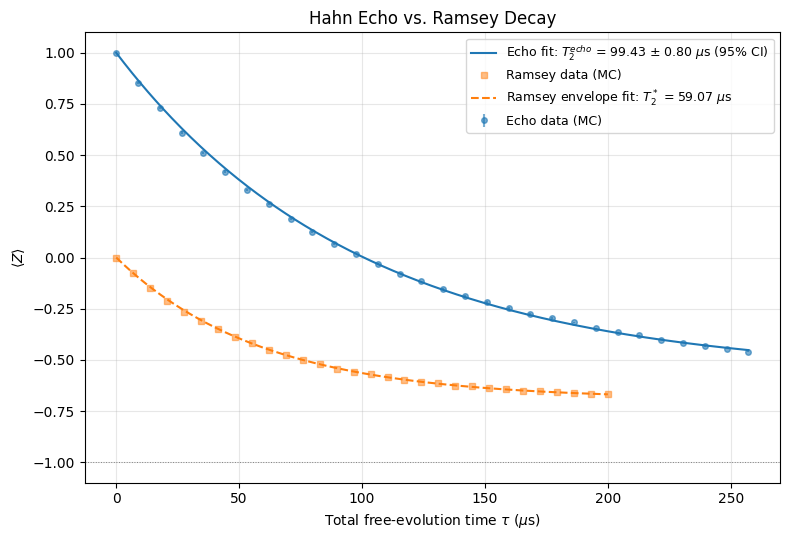

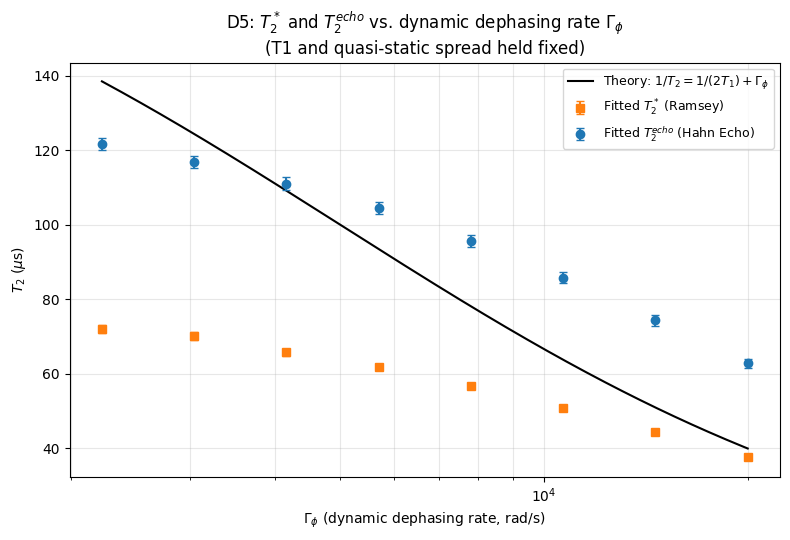

In [15]:
if __name__ == "__main__":
    T1 = T1_DEFAULT
    T_phi_dynamic_ref = T_PHI_DYNAMIC
    T2_star_ref = T2_STAR_DEFAULT

    # Fixed quasi-static spread, backed out from the reference T2* target.
    T2_dynamic_ref = 1.0 / (1.0 / (2 * T1) + 1.0 / T_phi_dynamic_ref)
    gamma_static = max(1.0 / T2_star_ref - 1.0 / T2_dynamic_ref, 0.0)

    print(f"T1                = {T1*1e6:.1f} us")
    print(f"T2_dynamic (ref)  = {T2_dynamic_ref*1e6:.2f} us")
    print(f"gamma_static      = {gamma_static/2/np.pi/1e3:.2f} kHz (1/2pi), fixed for all sweeps")

    # ---- Single-point comparison (as before) --------------------------------
    print("\n--- Single-point Hahn Echo vs Ramsey ---")
    echo_result = run_hahn_echo(T1, T_phi_dynamic_ref, gamma_static)
    ramsey_taus, ramsey_z, ramsey_popt, ramsey_perr = run_ramsey_for_comparison(
        T1, T_phi_dynamic_ref, gamma_static)

    print(f"T2_echo = {echo_result['T2_echo']*1e6:.3f} us "
          f"+/- {echo_result['T2_echo_ci95']*1e6:.3f} us (95% CI)")
    print(f"T2*     = {ramsey_popt[1]*1e6:.3f} us "
          f"+/- {1.96*ramsey_perr[1]*1e6:.3f} us (95% CI)")
    print(f"Echo improvement factor T2_echo / T2* = "
          f"{echo_result['T2_echo']/ramsey_popt[1]:.2f}")
    print(f"Sanity check T2_echo <= 2*T1 = {2*T1*1e6:.1f} us: "
          f"{'OK' if echo_result['T2_echo'] <= 2*T1 else 'VIOLATED'}")

    fig1 = plot_single_comparison(echo_result, ramsey_taus, ramsey_z, ramsey_popt,
                                   save_path="report/figures/hahn_echo.png")

    # ---- D5: Parameter sweep over Gamma_phi (one order of magnitude) --------
    print("\n--- D5 Parameter Sweep: T_phi_dynamic across one order of magnitude ---")
    T_phi_values = np.geomspace(T_phi_dynamic_ref / 3, T_phi_dynamic_ref * 3, 8)
    # e.g. ~ [50, ..., 450] us -> spans just over one order of magnitude in Tphi
    # (equivalently in Gamma_phi = 1/Tphi)

    sweep_results = parameter_sweep(T1, T_phi_values, gamma_static,
                                     n_points=20, n_shots=1500)

    # Rename keys to match what plot_sweep expects
    if 'T2_star_error' in sweep_results and 'T2_star_err' not in sweep_results:
        sweep_results['T2_star_err'] = sweep_results.pop('T2_star_error')
    if 'T2_echo_error' in sweep_results and 'T2_echo_err' not in sweep_results:
        sweep_results['T2_echo_err'] = sweep_results.pop('T2_echo_error')

    fig2 = plot_sweep(sweep_results, T1, save_path=None)

    plt.show()

In [16]:
print(len(sweep_results["Gamma_phi"]))
print(sweep_results["Gamma_phi"])
print(sweep_results["T2_star"])
print(sweep_results["T2_echo"])

8
[20000.         14611.99911286 10675.52590372  7799.53875172
  5698.34266605  4163.20889905  3041.64023698  2222.22222222]
[3.77594958e-05 4.45285039e-05 5.08860330e-05 5.68708976e-05
 6.19688752e-05 6.58034306e-05 7.01809320e-05 7.20659007e-05]
[6.28460099e-05 7.43320698e-05 8.58475699e-05 9.56961565e-05
 1.04489810e-04 1.11051743e-04 1.16889958e-04 1.21659200e-04]


In [17]:
print(T_phi_values)
print(len(T_phi_values))

[5.00000000e-05 6.84369053e-05 9.36722002e-05 1.28212710e-04
 1.75489622e-04 2.40199333e-04 3.28769980e-04 4.50000000e-04]
8
